In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import random

In [8]:
genders = ['Male', 'Female', 'Other']
payment_modes = ['Cash', 'Card', 'UPI', 'Wallet']
product_categories = ['Electronics', 'Clothing', 'Grocery', 'Furniture']

data = []

for i in range(1, 51):   # 50 entries
    row = [
        i,
        random.choice(genders),
        random.choice(payment_modes),
        random.choice(product_categories)
    ]
    data.append(row)

# Create DataFrame
df = pd.DataFrame(data, columns=[
    'Customer_ID',
    'Gender',
    'Payment_Mode',
    'Product_Category'
])

# Save as CSV
df.to_csv('customer_purchase.csv', index=False)

print("Dataset Created Successfully!")

Dataset Created Successfully!


In [9]:
df = pd.read_csv('customer_purchase.csv')

print("\nDataset Preview:")
print(df.head())


Dataset Preview:
   Customer_ID  Gender Payment_Mode Product_Category
0            1    Male         Cash          Grocery
1            2    Male          UPI          Grocery
2            3    Male       Wallet      Electronics
3            4  Female         Card        Furniture
4            5  Female          UPI         Clothing


In [10]:
print("\nProduct Category Distribution:")
print(df['Product_Category'].value_counts())

print("\nPayment Mode Distribution:")
print(df['Payment_Mode'].value_counts())


Product Category Distribution:
Product_Category
Clothing       16
Electronics    13
Furniture      13
Grocery         8
Name: count, dtype: int64

Payment Mode Distribution:
Payment_Mode
Cash      15
UPI       14
Wallet    14
Card       7
Name: count, dtype: int64


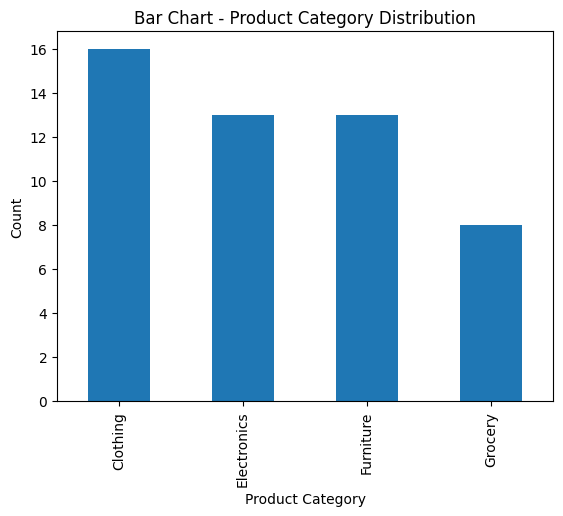

In [11]:
df['Product_Category'].value_counts().plot(kind='bar')
plt.title("Bar Chart - Product Category Distribution")
plt.xlabel("Product Category")
plt.ylabel("Count")
plt.show()

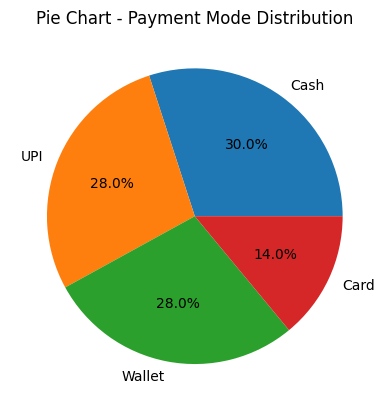

In [12]:
plt.figure()
df['Payment_Mode'].value_counts().plot(kind='pie', autopct='%1.1f%%')
plt.title("Pie Chart - Payment Mode Distribution")
plt.ylabel("")
plt.show()

In [13]:
print("\nGender Distribution:")
print(df['Gender'].value_counts())


Gender Distribution:
Gender
Other     24
Male      14
Female    12
Name: count, dtype: int64



Gender vs Product Category:
Product_Category  Clothing  Electronics  Furniture  Grocery
Gender                                                     
Female                   3            5          3        1
Male                     7            1          3        3
Other                    6            7          7        4


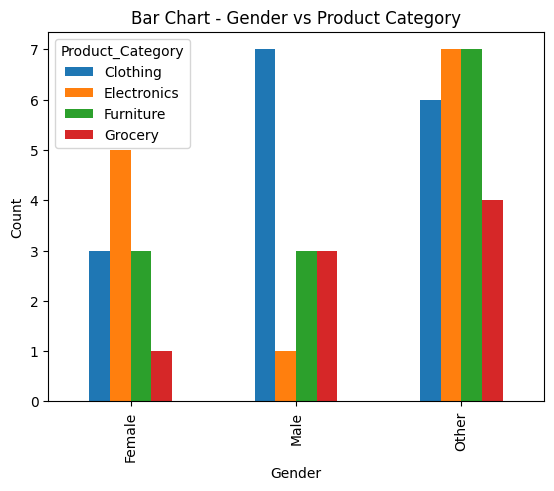

In [14]:
gender_product = df.groupby(['Gender', 'Product_Category']).size().unstack()

print("\nGender vs Product Category:")
print(gender_product)

gender_product.plot(kind='bar')
plt.title("Bar Chart - Gender vs Product Category")
plt.xlabel("Gender")
plt.ylabel("Count")
plt.show()

In [19]:
import pandas as pd
import numpy as np

np.random.seed(1)

data = {
    "Reading_ID": range(1, 101),
    "Time": np.tile(range(0, 24), 5)[:100],  # Hours repeated
    "Temperature_C": np.round(np.random.normal(30, 4, 100), 2),
    "Humidity_%": np.round(np.random.normal(60, 8, 100), 2),
    "Air_Quality_Index": np.round(np.random.normal(100, 15, 100), 2)
}

df = pd.DataFrame(data)

df.to_csv("sensor_readings.csv", index=False)

print("Dataset Created Successfully!")


Dataset Created Successfully!


In [20]:
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("sensor_readings.csv")

print("Dataset Preview:")
print(df.head())

print("\nData Types:")
print(df.dtypes)


Dataset Preview:
   Reading_ID  Time  Temperature_C  Humidity_%  Air_Quality_Index
0           1     0          36.50       56.42              93.99
1           2     1          27.55       69.80             112.36
2           3     2          27.89       63.23              91.57
3           4     3          25.71       64.75             129.32
4           5     4          33.46       51.24              80.02

Data Types:
Reading_ID             int64
Time                   int64
Temperature_C        float64
Humidity_%           float64
Air_Quality_Index    float64
dtype: object


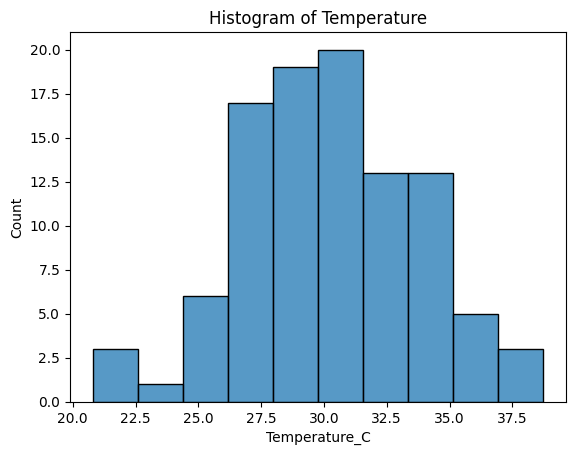

In [21]:
plt.figure()
sns.histplot(df["Temperature_C"], bins=10)
plt.title("Histogram of Temperature")
plt.show()


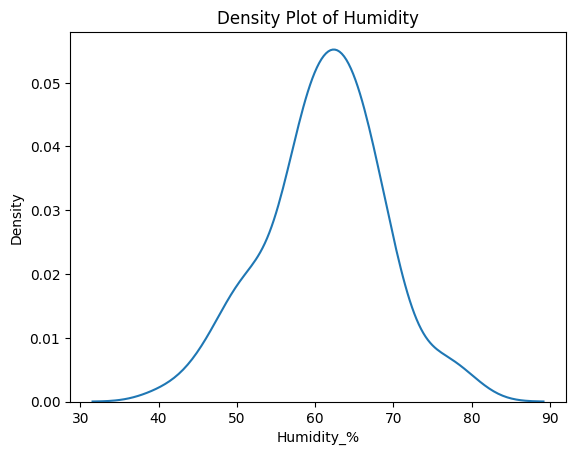

In [22]:
plt.figure()
sns.kdeplot(df["Humidity_%"])
plt.title("Density Plot of Humidity")
plt.show()


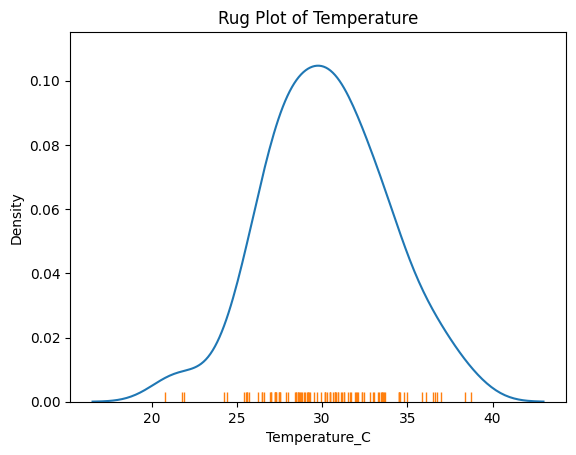

In [23]:
plt.figure()
sns.kdeplot(df["Temperature_C"])
sns.rugplot(df["Temperature_C"])
plt.title("Rug Plot of Temperature")
plt.show()


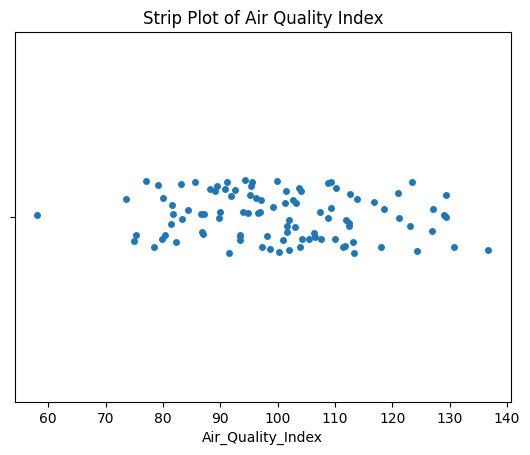

In [24]:
plt.figure()
sns.stripplot(x=df["Air_Quality_Index"])
plt.title("Strip Plot of Air Quality Index")
plt.show()


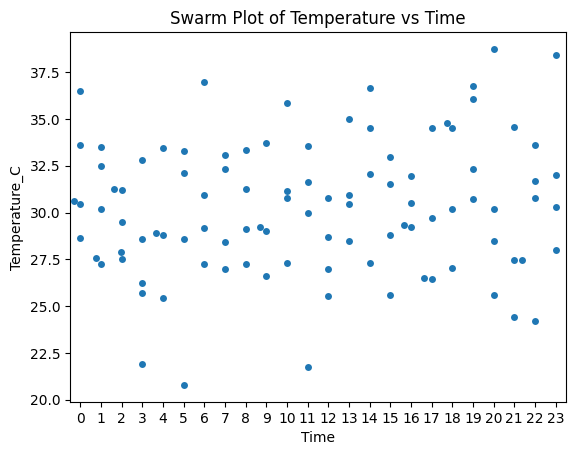

In [25]:
plt.figure()
sns.swarmplot(x="Time", y="Temperature_C", data=df)
plt.title("Swarm Plot of Temperature vs Time")
plt.show()


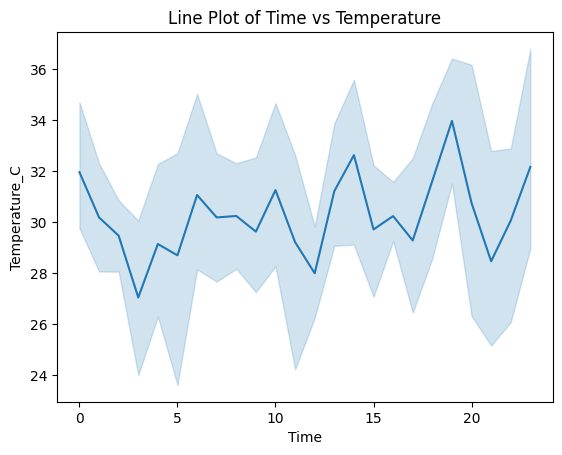

In [26]:
plt.figure()
sns.lineplot(x="Time", y="Temperature_C", data=df)
plt.title("Line Plot of Time vs Temperature")
plt.show()


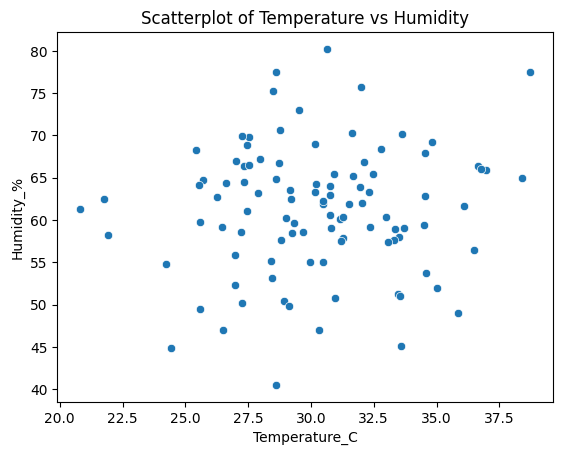

In [27]:
plt.figure()
sns.scatterplot(x="Temperature_C", y="Humidity_%", data=df)
plt.title("Scatterplot of Temperature vs Humidity")
plt.show()


In [28]:
print("Summary Statistics:")
print(df.describe())

print("\nSkewness of AQI:", df["Air_Quality_Index"].skew())
print("Kurtosis of AQI:", df["Air_Quality_Index"].kurt())


Summary Statistics:
       Reading_ID        Time  Temperature_C  Humidity_%  Air_Quality_Index
count  100.000000  100.000000     100.000000   100.00000         100.000000
mean    50.500000   11.100000      30.242300    61.22250         100.147200
std     29.011492    7.098869       3.558679     7.49392          15.150013
min      1.000000    0.000000      20.790000    40.52000          58.100000
25%     25.750000    5.000000      27.542500    57.60250          89.715000
50%     50.500000   11.000000      30.255000    61.89500         100.110000
75%     75.250000   17.000000      32.550000    65.94000         109.970000
max    100.000000   23.000000      38.740000    80.23000         136.740000

Skewness of AQI: 0.1308165141581739
Kurtosis of AQI: -0.18292788702999108
